# Vamos a tratar de genera un presure bump.

Queremos generar un pressure bump en alguna parte, ademas, tambien vamos a agregar el efecto del hielo y H2O. Pero obviamete lo haremos despues porque hacerlo todo ahora seria mucho

Primero generamos nuestra simulacion y nuestra grilla

Usaremos los parametros defualt, pero con mas Nr para mas resolucion



In [1]:
from tripodpy import Simulation
import dustpy.constants as c
from tripodpy import plot
import numpy as np


In [2]:
sim = Simulation()

In [3]:
sim.ini.grid.Nr = 150

In [4]:
sim.makegrids()

In [5]:
# Ocuparemos los snapshtos default.
sim.gas
# Tendremos que inicializar para poder modifica el gas.Sigma

Group (Gas quantities)
----------------------
    boundary     : Group (Boundary conditions)
    S            : Group (Source terms)
    torque       : Group (Torque parameters)
    v            : Group (Velocities)
  -----
    alpha        : NoneType
    cs           : NoneType
    eta          : NoneType
    Fi           : NoneType
    Hp           : NoneType
    mfp          : NoneType
    mu           : NoneType
    n            : NoneType
    nu           : NoneType
    P            : NoneType
    rho          : NoneType
    Sigma        : NoneType
    SigmaFloor   : NoneType
    T            : NoneType
  -----

In [6]:
sim.initialize()

## Intentamos modificar el perfil de $\Sigma_{gas}$ para poder generar gradientes de presion y por lo tanto generar gaps.


In [7]:
def add_pressure_bump(sim, r0=30*c.au, width=5*c.au, A=1.0):
    r = sim.grid.r
    bump = 1 + A * np.exp(- (r - r0)**2 / (2 * width**2))
    sim.gas.Sigma *= bump
    
# Ocupamos el caso default
add_pressure_bump(sim, A=50)

In [8]:
add_pressure_bump(sim, r0=100*c.au, width=10*c.au, A=100)

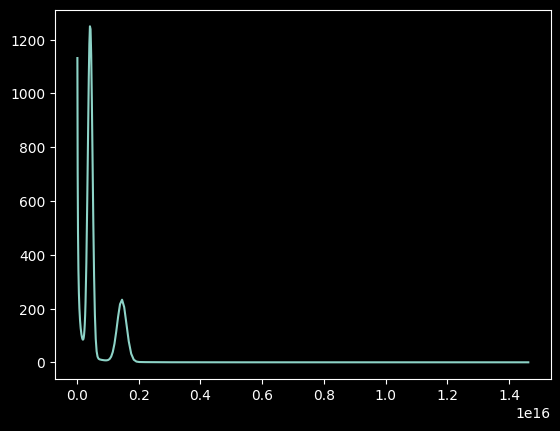

In [9]:
import matplotlib.pyplot as plt

plt.plot(sim.grid.r, sim.gas.Sigma)

In [10]:
sim.writer.datadir = "pb_v2"
sim.update()

In [11]:
sim.run()


tripodpy v1.0.0

Creating data directory pb_v2.
Writing file pb_v2\data0000.hdf5
Writing dump file pb_v2\frame.dmp
Writing file pb_v2\data0001.hdf5
Writing dump file pb_v2\frame.dmp
Writing file pb_v2\data0002.hdf5
Writing dump file pb_v2\frame.dmp
Writing file pb_v2\data0003.hdf5
Writing dump file pb_v2\frame.dmp
Writing file pb_v2\data0004.hdf5
Writing dump file pb_v2\frame.dmp
Writing file pb_v2\data0005.hdf5
Writing dump file pb_v2\frame.dmp
Writing file pb_v2\data0006.hdf5
Writing dump file pb_v2\frame.dmp
Writing file pb_v2\data0007.hdf5
Writing dump file pb_v2\frame.dmp
Writing file pb_v2\data0008.hdf5
Writing dump file pb_v2\frame.dmp
Writing file pb_v2\data0009.hdf5
Writing dump file pb_v2\frame.dmp
Writing file pb_v2\data0010.hdf5
Writing dump file pb_v2\frame.dmp
Writing file pb_v2\data0011.hdf5
Writing dump file pb_v2\frame.dmp
Writing file pb_v2\data0012.hdf5
Writing dump file pb_v2\frame.dmp
Writing file pb_v2\data0013.hdf5
Writing dump file pb_v2\frame.dmp
Writing file 

In [12]:
from grid_extension import plot_disk_diagnostics_multicomp

c:\astro\Codigos practica + docs + papers\codigos\grid_extension.py:196: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  axs[1, 1].axhline(1.0, color='white', linestyle=':', label='Límite $\epsilon = 1$', alpha=0.5)


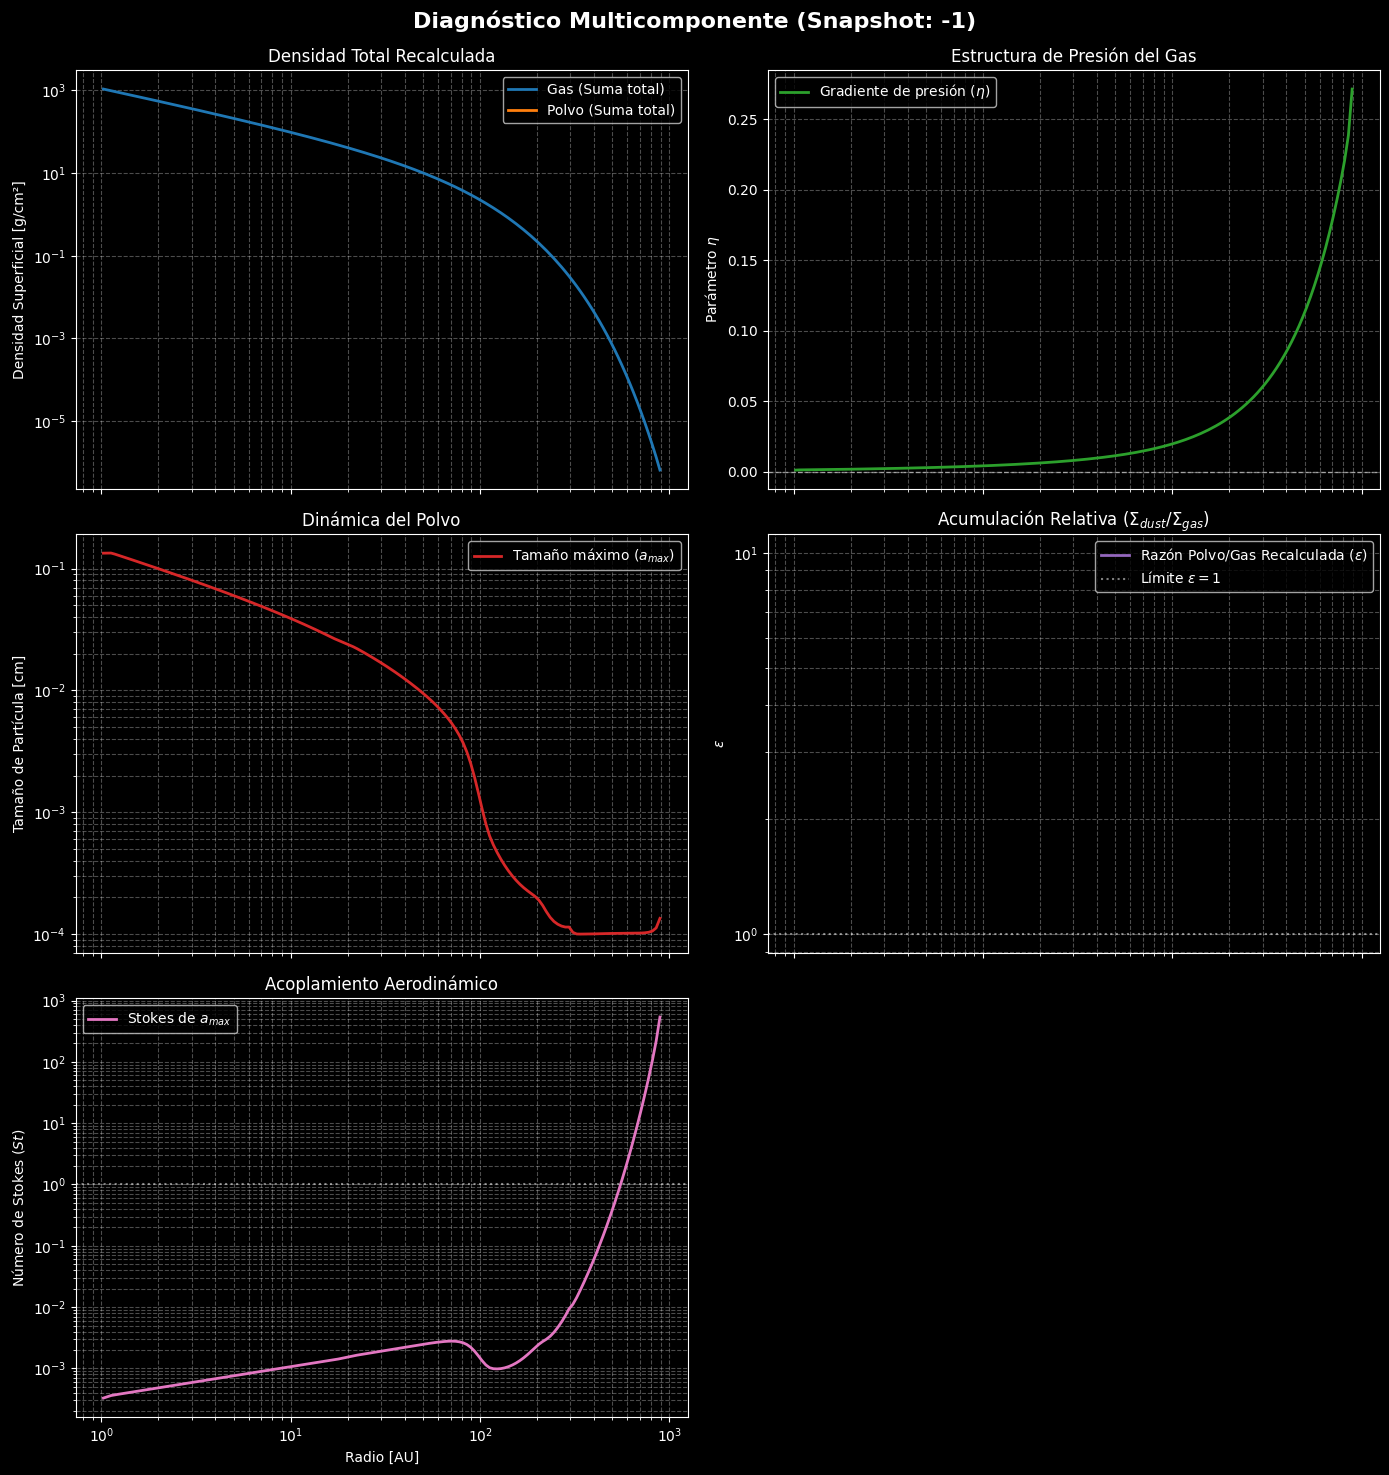

In [13]:
plot_disk_diagnostics_multicomp(sim)

---
No pude hacer nada satisfactorio

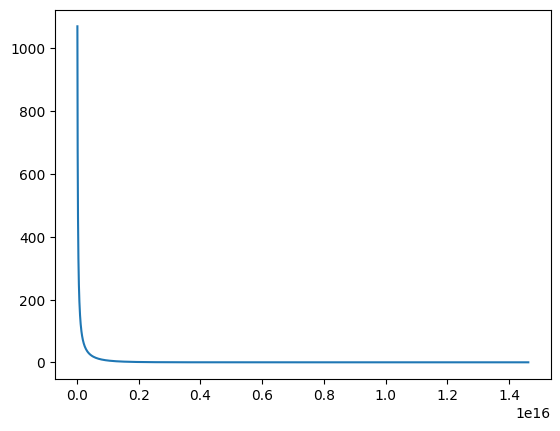

In [15]:
plt.plot(sim.grid.r, sim.gas.Sigma)
# Se volvio a modificar.

## Usamos ahora el parametro Alpha, primer intento. No funcion, mejor modificar el updater

In [18]:
# NO tocamos sim.gas.Sigma ; en su lugar causamos un "bache" de viscosidad (Dead zone localizada)

def create_alpha_dip(sim, r0=30*c.au, width=5*c.au):
    base_alpha = 1e-3  # Turbulencia estándar
    bump_alpha = 1e-4  # Reducimos 1 orden de magnitud de viscosidad justo en nuestra trampa 
    
    r = sim.grid.r
    
    # Hacemos que alpha decaiga en forma de campana en r0
    caida = (base_alpha - bump_alpha) * np.exp(- (r - r0)**2 / (2 * width**2))
    nuevo_alpha = base_alpha - caida
    
    # Guardamos este arreglo espacial como matriz de alpha en nuestro disco
    sim.gas.alpha = nuevo_alpha
    sim.update()

# Iniciamos los parámetros estándares

sim = Simulation()
sim.makegrids()

sim.initialize()

create_alpha_dip(sim, r0=30*c.au, width=5*c.au)
create_alpha_dip(sim, r0=100*c.au, width=10*c.au)

# Aplicamos las caídas en alpha

# Ejecutamos la simulación
sim.writer.datadir = "bumps/pb_v4"
sim.run()



tripodpy v1.0.0

Creating data directory bumps\pb_v4.
Writing file bumps\pb_v4\data0000.hdf5
Writing dump file bumps\pb_v4\frame.dmp
Writing file bumps\pb_v4\data0001.hdf5
Writing dump file bumps\pb_v4\frame.dmp
Writing file bumps\pb_v4\data0002.hdf5
Writing dump file bumps\pb_v4\frame.dmp
Writing file bumps\pb_v4\data0003.hdf5
Writing dump file bumps\pb_v4\frame.dmp
Writing file bumps\pb_v4\data0004.hdf5
Writing dump file bumps\pb_v4\frame.dmp
Writing file bumps\pb_v4\data0005.hdf5
Writing dump file bumps\pb_v4\frame.dmp
Writing file bumps\pb_v4\data0006.hdf5
Writing dump file bumps\pb_v4\frame.dmp
Writing file bumps\pb_v4\data0007.hdf5
Writing dump file bumps\pb_v4\frame.dmp
Writing file bumps\pb_v4\data0008.hdf5
Writing dump file bumps\pb_v4\frame.dmp
Writing file bumps\pb_v4\data0009.hdf5
Writing dump file bumps\pb_v4\frame.dmp
Writing file bumps\pb_v4\data0010.hdf5
Writing dump file bumps\pb_v4\frame.dmp
Writing file bumps\pb_v4\data0011.hdf5
Writing dump file bumps\pb_v4\frame.d

## Modificamos la viscosidad del disco, actualizando el updater del parametro alpha (viscosidad) generando Dead Zones. Fue posible generar gaps.

In [20]:
# 1. Función que calculará la viscosidad en CADA loop de integración
def alpha_dip_updater(sim):
    base_alpha = 1e-3  # Viscosidad normal
    bump_alpha = 1e-4  # Reducida fuertemente en el bache
    
    r0_1 = 30 * c.au  ;  width_1 = 5 * c.au
    r0_2 = 100 * c.au ;  width_2 = 10 * c.au
    
    r = sim.grid.r
    
    # Campanas de caída en viscosidad
    dip_1 = (base_alpha - bump_alpha) * np.exp(- (r - r0_1)**2 / (2 * width_1**2))
    dip_2 = (base_alpha - bump_alpha) * np.exp(- (r - r0_2)**2 / (2 * width_2**2))
    
    nuevo_alpha = base_alpha - dip_1 - dip_2
    
    # Seguridad numérica
    return np.maximum(nuevo_alpha, bump_alpha)


sim = Simulation() 
sim.ini.grid.Nr = 150

# 2. Inicialización obligatoria previa a modificar updaters
sim.makegrids()
sim.initialize()

# 3. AQUÍ aplicas tu magia: intervenimos directamente el núcleo calculador
sim.gas.alpha.updater.updater = alpha_dip_updater

# 4. Actualizamos manualmente el frame antes de la primera corrida para fijar los cálculos base
sim.gas.alpha.update()
sim.update()

# 5. Ejecutamos! (Veo que en tu código interactivo llamaste a la carpeta pb_v3, excelente)
sim.writer.datadir = "bumps/pb_v5"
sim.run()



tripodpy v1.0.0

Creating data directory bumps\pb_v5.
Writing file bumps\pb_v5\data0000.hdf5
Writing dump file bumps\pb_v5\frame.dmp
Writing file bumps\pb_v5\data0001.hdf5
Writing dump file bumps\pb_v5\frame.dmp
Writing file bumps\pb_v5\data0002.hdf5
Writing dump file bumps\pb_v5\frame.dmp
Writing file bumps\pb_v5\data0003.hdf5
Writing dump file bumps\pb_v5\frame.dmp
Writing file bumps\pb_v5\data0004.hdf5
Writing dump file bumps\pb_v5\frame.dmp
Writing file bumps\pb_v5\data0005.hdf5
Writing dump file bumps\pb_v5\frame.dmp
Writing file bumps\pb_v5\data0006.hdf5
Writing dump file bumps\pb_v5\frame.dmp
Writing file bumps\pb_v5\data0007.hdf5
Writing dump file bumps\pb_v5\frame.dmp
Writing file bumps\pb_v5\data0008.hdf5
Writing dump file bumps\pb_v5\frame.dmp
Writing file bumps\pb_v5\data0009.hdf5
Writing dump file bumps\pb_v5\frame.dmp
Writing file bumps\pb_v5\data0010.hdf5
Writing dump file bumps\pb_v5\frame.dmp
Writing file bumps\pb_v5\data0011.hdf5
Writing dump file bumps\pb_v5\frame.d

c:\astro\Codigos practica + docs + papers\codigos\grid_extension.py:196: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  axs[1, 1].axhline(1.0, color='white', linestyle=':', label='Límite $\epsilon = 1$', alpha=0.5)


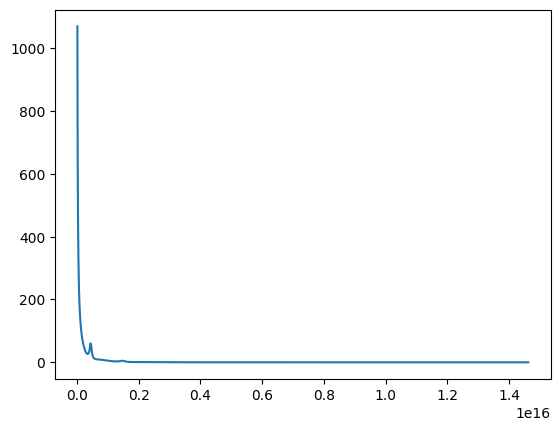

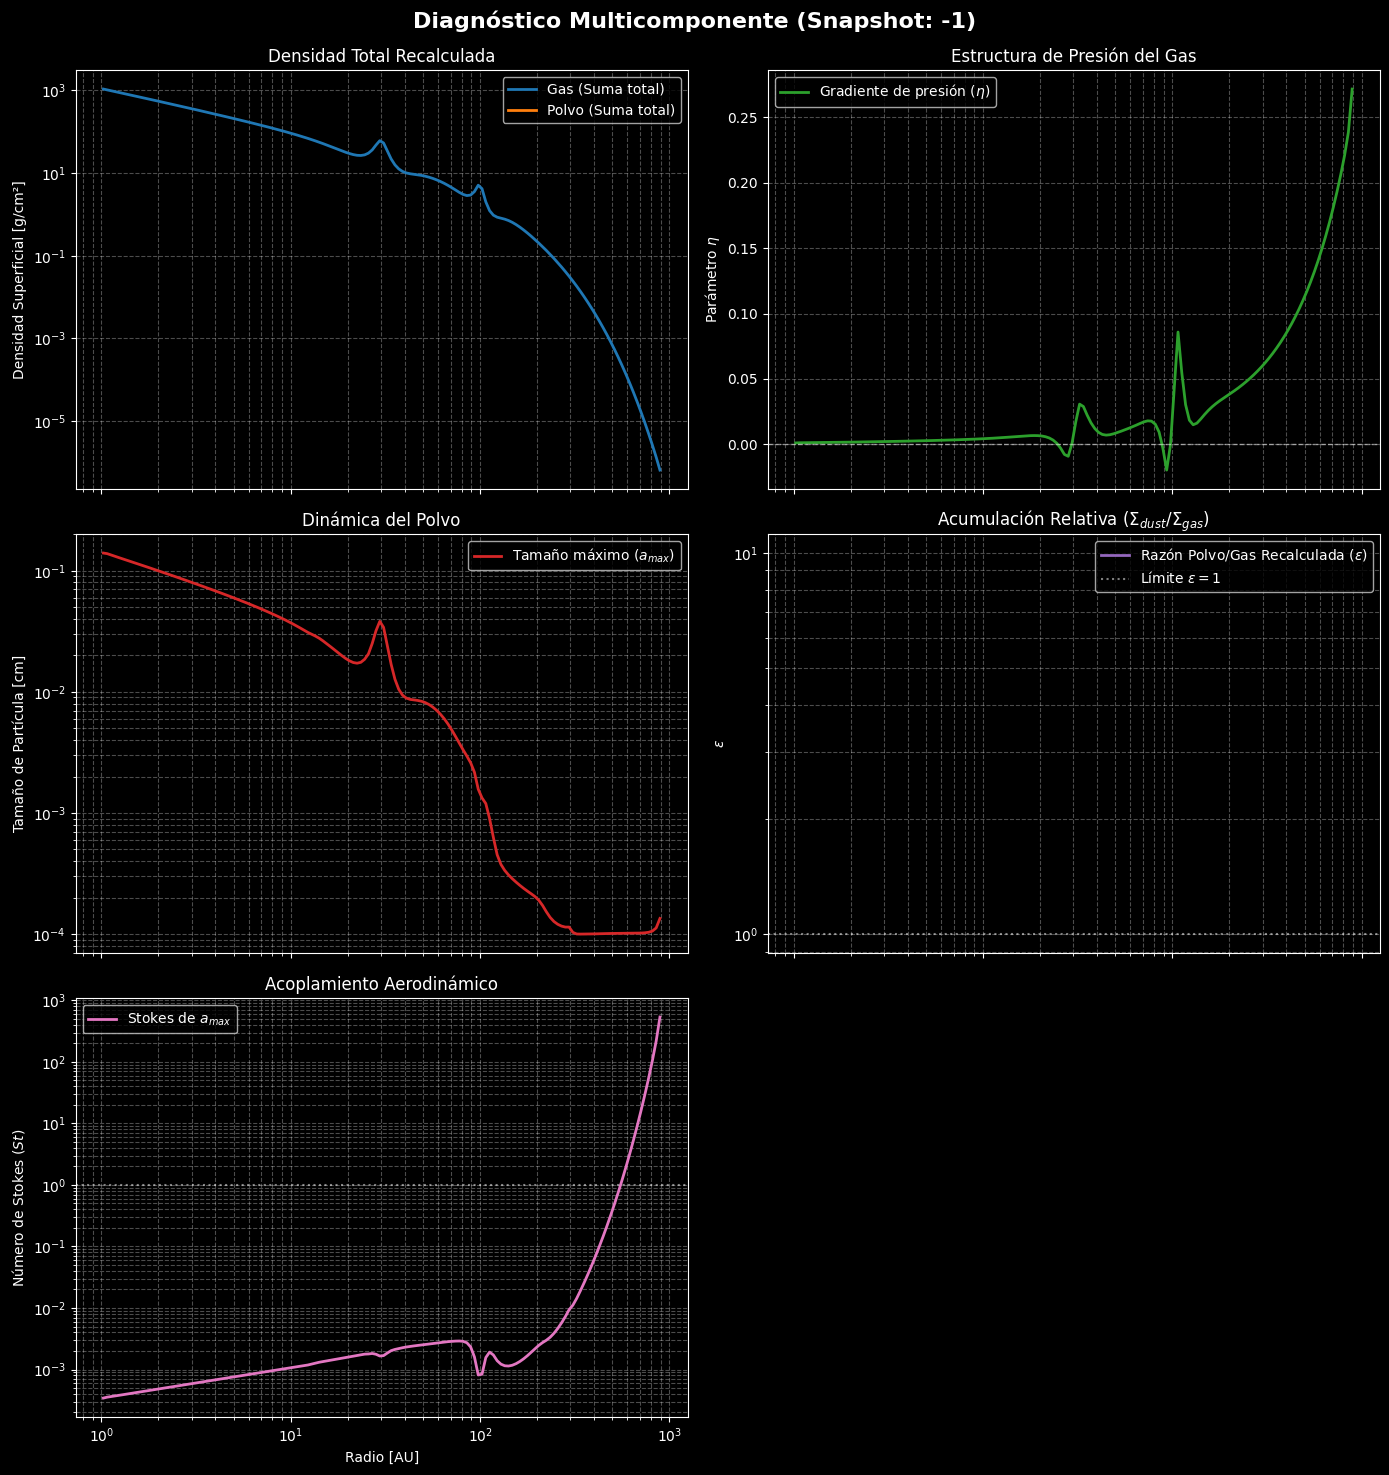

In [22]:
plt.plot(sim.grid.r, sim.gas.Sigma)
# Esta bien si se mantuvo un Sigma diferente.
plot_disk_diagnostics_multicomp(sim)

## Volvemos a intenter modificar el sigma con un enfoque difernte para ver si podemos generar gaps

In [23]:
sim = Simulation()
sim.ini.grid.Nr = 150
sim.makegrids()
sim.initialize()

# 1. IMPORTANTÍSIMO: Guardamos una foto de la masa original inmaculada
sigma_base = sim.gas.Sigma.copy()

# 2. Nuestro updater controlador del perfil de densidades
def forzar_sigma_bump(sim):
    # La máxima amplitud del obstáculo
    A1 = 5.0
    A2 = 5.0
    r = sim.grid.r
    
    # Creamos las dos campanas
    bump1 = A1 * np.exp(- (r - 30*c.au)**2 / (2 * (5*c.au)**2))
    bump2 = A2 * np.exp(- (r - 100*c.au)**2 / (2 * (10*c.au)**2))
    
    # "PISO" el valor difuminado calculado por el integrador
    # imponiendo nuestro tope de masa basado estrictamente en al ambiente original
    sim.gas.Sigma = sigma_base * (1 + bump1 + bump2)
    
    return 0. # Devuelve cero porque a este Campo inyector no le importa el valor en sí.

# 3. La MAGIA usando un "Gancho" o Hook como lo vimos en el notebook 3
sim.gas.addfield("imposicion_densidad", 0.)
sim.gas.imposicion_densidad.updater.updater = forzar_sigma_bump

# Inyectamos este hook como el PRIMERO (índice 0) en ejecutarse al actualizar el gas
# Así, todas las variables de presión, gravedad y difusión se subordinarán a esta pared de masa!
sim.gas.updateorder.insert(0, "imposicion_densidad")

# Instanciamos manualmente esta fuerza bruta y actualizamos la física
sim.gas.imposicion_densidad.update()
sim.update()

# Corremos la simulación 
sim.writer.datadir = "bumps/pb_v6"
sim.run()



tripodpy v1.0.0

Creating data directory bumps\pb_v6.
Writing file bumps\pb_v6\data0000.hdf5
Writing dump file bumps\pb_v6\frame.dmp
Writing file bumps\pb_v6\data0001.hdf5
Writing dump file bumps\pb_v6\frame.dmp
Writing file bumps\pb_v6\data0002.hdf5
Writing dump file bumps\pb_v6\frame.dmp
Writing file bumps\pb_v6\data0003.hdf5
Writing dump file bumps\pb_v6\frame.dmp
Writing file bumps\pb_v6\data0004.hdf5
Writing dump file bumps\pb_v6\frame.dmp
Writing file bumps\pb_v6\data0005.hdf5
Writing dump file bumps\pb_v6\frame.dmp
Writing file bumps\pb_v6\data0006.hdf5
Writing dump file bumps\pb_v6\frame.dmp
Writing file bumps\pb_v6\data0007.hdf5
Writing dump file bumps\pb_v6\frame.dmp
Writing file bumps\pb_v6\data0008.hdf5
Writing dump file bumps\pb_v6\frame.dmp
Writing file bumps\pb_v6\data0009.hdf5
Writing dump file bumps\pb_v6\frame.dmp
Writing file bumps\pb_v6\data0010.hdf5
Writing dump file bumps\pb_v6\frame.dmp
Writing file bumps\pb_v6\data0011.hdf5
Writing dump file bumps\pb_v6\frame.d

c:\astro\Codigos practica + docs + papers\codigos\grid_extension.py:196: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  axs[1, 1].axhline(1.0, color='white', linestyle=':', label='Límite $\epsilon = 1$', alpha=0.5)


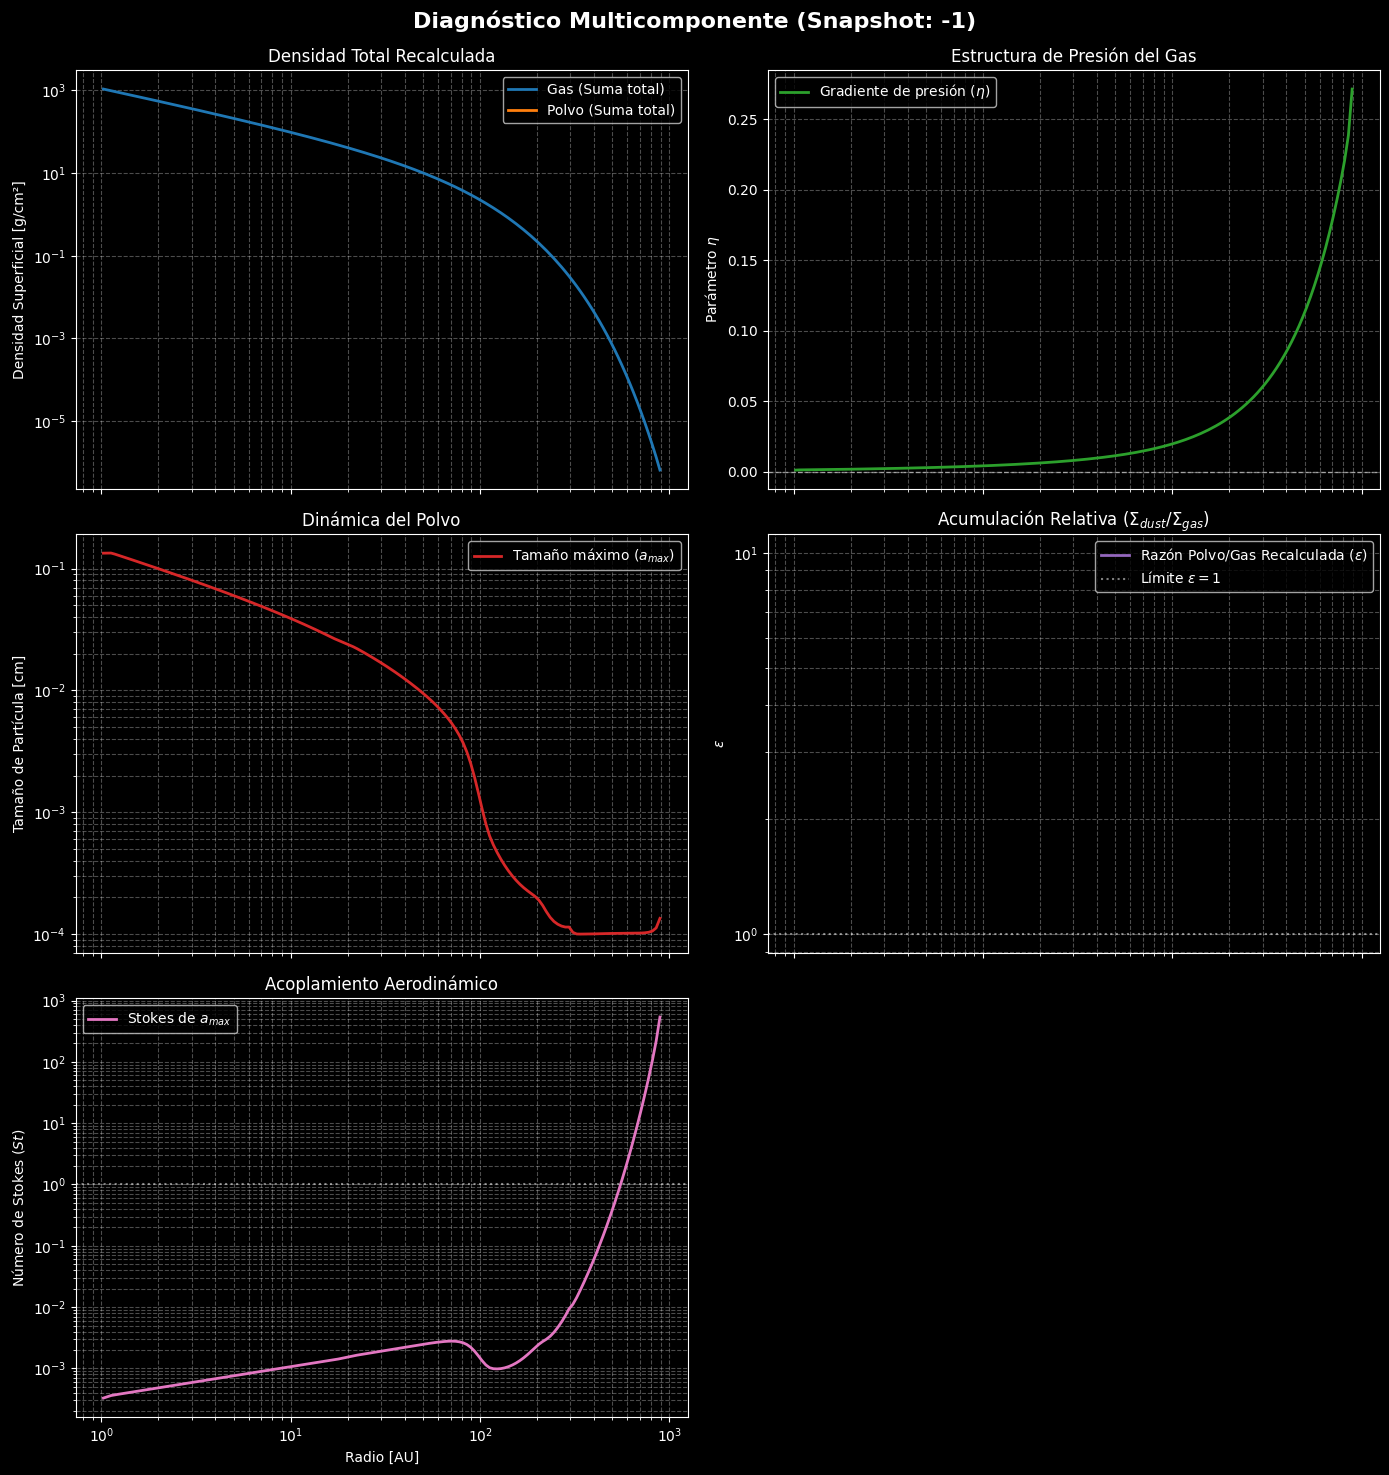

In [24]:
plot_disk_diagnostics_multicomp(sim)

In [25]:
sim = Simulation()
sim.ini.grid.Nr = 150
sim.makegrids()
sim.initialize()

# 1. IMPORTANTÍSIMO: Guardamos una foto de la masa original inmaculada
sigma_base = sim.gas.Sigma.copy()

def forzar_sigma_bump(sim):
    A1 = 5.0
    A2 = 5.0
    r = sim.grid.r
    
    bump1 = A1 * np.exp(- (r - 30*c.au)**2 / (2 * (5*c.au)**2))
    bump2 = A2 * np.exp(- (r - 100*c.au)**2 / (2 * (10*c.au)**2))
    
    # LA DIFERENCIA MAGISTRAL:
    # Agregando [:] forzamos la mutación en la misma celda de memoria (In-place)
    # ahora el motor de simulación SÍ siente este machaqueo constante
    sim.gas.Sigma[:] = sigma_base * (1 + bump1 + bump2)
    
    return 0.
# Mismo hook que antes...
sim.gas.addfield("imposicion_densidad", 0.)
sim.gas.imposicion_densidad.updater.updater = forzar_sigma_bump
sim.gas.updateorder.insert(0, "imposicion_densidad")
# ¡A ejecutar!
sim.gas.imposicion_densidad.update()
sim.update()

# Corremos la simulación 
sim.writer.datadir = "bumps/pb_v7"
sim.run()



tripodpy v1.0.0

Creating data directory bumps\pb_v7.
Writing file bumps\pb_v7\data0000.hdf5
Writing dump file bumps\pb_v7\frame.dmp
Writing file bumps\pb_v7\data0001.hdf5
Writing dump file bumps\pb_v7\frame.dmp
Writing file bumps\pb_v7\data0002.hdf5
Writing dump file bumps\pb_v7\frame.dmp
Writing file bumps\pb_v7\data0003.hdf5
Writing dump file bumps\pb_v7\frame.dmp
Writing file bumps\pb_v7\data0004.hdf5
Writing dump file bumps\pb_v7\frame.dmp
Writing file bumps\pb_v7\data0005.hdf5
Writing dump file bumps\pb_v7\frame.dmp
Writing file bumps\pb_v7\data0006.hdf5
Writing dump file bumps\pb_v7\frame.dmp
Writing file bumps\pb_v7\data0007.hdf5
Writing dump file bumps\pb_v7\frame.dmp
Writing file bumps\pb_v7\data0008.hdf5
Writing dump file bumps\pb_v7\frame.dmp
Writing file bumps\pb_v7\data0009.hdf5
Writing dump file bumps\pb_v7\frame.dmp
Writing file bumps\pb_v7\data0010.hdf5
Writing dump file bumps\pb_v7\frame.dmp
Writing file bumps\pb_v7\data0011.hdf5
Writing dump file bumps\pb_v7\frame.d

c:\astro\Codigos practica + docs + papers\codigos\grid_extension.py:196: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  axs[1, 1].axhline(1.0, color='white', linestyle=':', label='Límite $\epsilon = 1$', alpha=0.5)


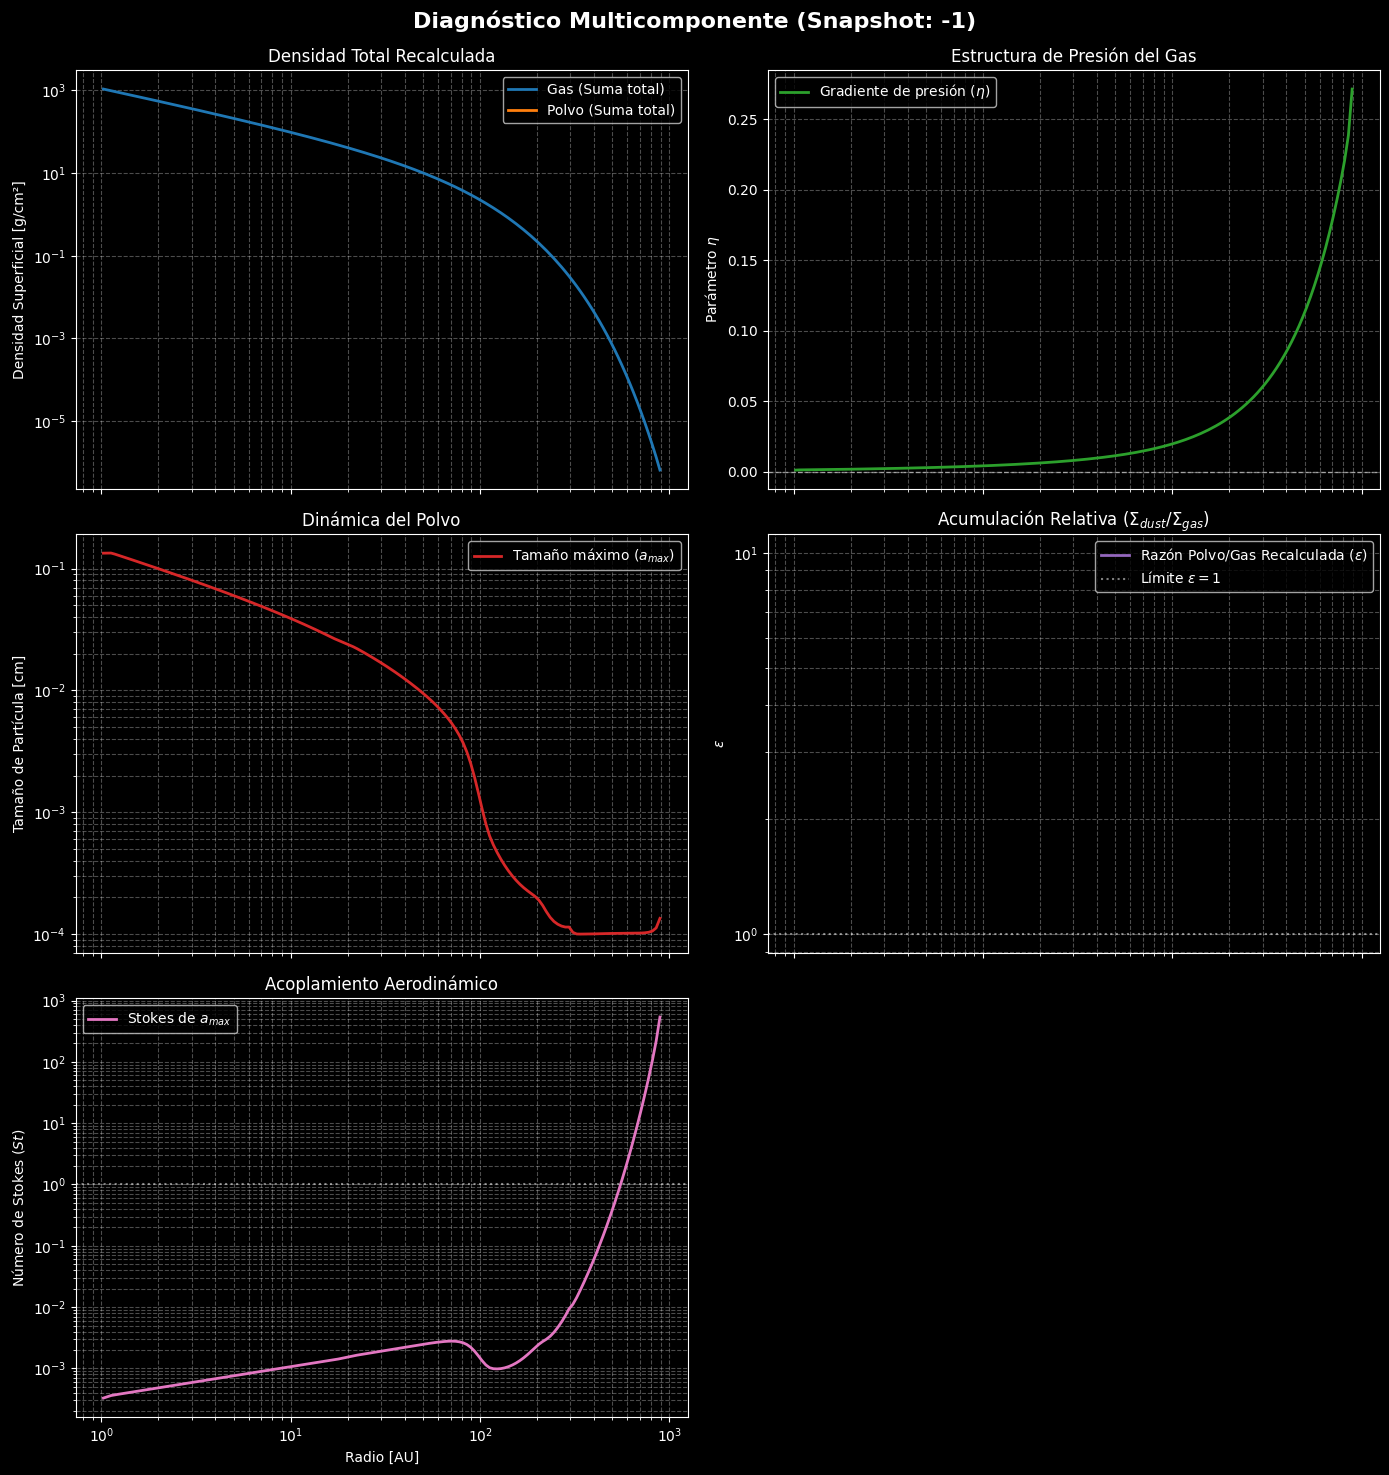

In [26]:
plot_disk_diagnostics_multicomp(sim)

In [27]:
sim = Simulation()
sim.ini.grid.Nr = 150
sim.makegrids()
sim.initialize()

# 1. IMPORTANTÍSIMO: Guardamos una foto de la masa original inmaculada
sigma_base = sim.gas.Sigma.copy()

# NUEVO: Calculador numérico REAL de gradientes de presión
def eta_numerico(sim):
    r = sim.grid.r
    P = sim.gas.P
    Hp = sim.gas.Hp
    
    # Calculamos la derivada Numérica Central: d(lnP) / d(lnR)
    dlnP = np.log(P[2:]) - np.log(P[:-2])
    dlnr = np.log(r[2:]) - np.log(r[:-2])
    
    eta = np.zeros_like(P)
    # Aplicamos paso a paso: eta = -0.5 * (Hp/r)^2 * (dlnP / dlnr)
    eta[1:-1] = -0.5 * (Hp[1:-1] / r[1:-1])**2 * (dlnP / dlnr)
    
    # Extrapolamos para que los dos bordes no tengan ruido
    eta[0] = eta[1]
    eta[-1] = eta[-2]
    
    return eta

# --- Tu hook de gas idéntico al de antes ---
def forzar_sigma_bump(sim):
    A1 = 5.0
    bump1 = A1 * np.exp(- (sim.grid.r - 30 * c.au)**2 / (2 * (5 * c.au)**2))
    sim.gas.Sigma[:] = sigma_base * (1 + bump1)
    return 0.

# 1. Inyectamos tu bloqueador de Gas
sim.gas.addfield("imposicion_densidad", 0.)
sim.gas.imposicion_densidad.updater.updater = forzar_sigma_bump
sim.gas.updateorder.insert(0, "imposicion_densidad")

# 2. LA MAGIA: Le asignamos la detección numérica a eta para que rastree el golpe
sim.gas.eta.updater.updater = eta_numerico

# Iniciar
sim.gas.imposicion_densidad.update()
sim.update()

sim.writer.datadir = "pb_v8"
sim.writer.overwrite = True
sim.run()



tripodpy v1.0.0

Creating data directory pb_v8.
Writing file pb_v8\data0000.hdf5
Writing dump file pb_v8\frame.dmp
Writing file pb_v8\data0001.hdf5
Writing dump file pb_v8\frame.dmp
Writing file pb_v8\data0002.hdf5
Writing dump file pb_v8\frame.dmp
Writing file pb_v8\data0003.hdf5
Writing dump file pb_v8\frame.dmp
Writing file pb_v8\data0004.hdf5
Writing dump file pb_v8\frame.dmp
Writing file pb_v8\data0005.hdf5
Writing dump file pb_v8\frame.dmp
Writing file pb_v8\data0006.hdf5
Writing dump file pb_v8\frame.dmp
Writing file pb_v8\data0007.hdf5
Writing dump file pb_v8\frame.dmp
Writing file pb_v8\data0008.hdf5
Writing dump file pb_v8\frame.dmp
Writing file pb_v8\data0009.hdf5
Writing dump file pb_v8\frame.dmp
Writing file pb_v8\data0010.hdf5
Writing dump file pb_v8\frame.dmp
Writing file pb_v8\data0011.hdf5
Writing dump file pb_v8\frame.dmp
Writing file pb_v8\data0012.hdf5
Writing dump file pb_v8\frame.dmp
Writing file pb_v8\data0013.hdf5
Writing dump file pb_v8\frame.dmp
Writing file 